In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
model_df = pd.read_csv(
    "../data/processed/model_dataset.csv"
)

model_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,match_id,home_form_5,home_avg_goals_5,home_avg_conceded_5,home_avg_goal_diff_5,away_form_5,away_avg_goals_5,away_avg_conceded_5,away_avg_goal_diff_5,goal_difference
0,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1500.000000,...,1,1.0,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,2
1,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1490.000000,...,2,1.0,1.000000,2.000000,-1.000000,4.0,2.000000,1.000000,1.000000,1
2,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1499.424989,...,3,4.0,1.666667,1.333333,0.333333,4.0,1.333333,1.666667,-0.333333,0
3,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1500.541911,...,4,5.0,1.500000,1.750000,-0.250000,5.0,1.750000,1.500000,0.250000,3
4,1877-03-03,England,Scotland,1,3,Friendly,London,England,False,1489.489284,...,6,5.0,1.400000,1.800000,-0.400000,10.0,2.600000,1.400000,1.200000,-2


In [19]:
model_df.shape

(22924, 22)

In [22]:
features = [
    "elo_diff",

    "home_form_5",
    "away_form_5",

    "home_avg_goals_5",
    "away_avg_goals_5",

    "home_avg_conceded_5",
    "away_avg_conceded_5",

    "home_avg_goal_diff_5",
    "away_avg_goal_diff_5"
]

In [23]:
X = model_df[features]

y = model_df["goal_difference"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(18339, 9)
(4585, 9)


In [26]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 0.01,-0.08, 0.06,..., 0.34, 0.25,-0.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['elo_diff','home_form_5','away_form_5',...,'away_avg_conceded_5', 'home_avg_goal_diff_5','away_avg_goal_diff_5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3787
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [27]:
y_pred = lr_model.predict(
    X_test
)

In [37]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)
# Error absoluto medio: El MAE indica cuántos goles se equivoca el modelo, en promedio, por partido.
print(f"MAE  : {mae:.4f}")
# Error cuadrático medio: El MSE penaliza más los errores grandes que los pequeños.
print(f"MSE  : {mse:.4f}")
# El RMSE mide el error típico del modelo y castiga especialmente las predicciones muy malas.
print(f"RMSE : {rmse:.4f}")
# Coeficiente de Determinación: que porcentaje del comportamiento de los resultados logra explicar el modelo.
print(f"R²   : {r2:.4f}")

MAE  : 1.5304
MSE  : 4.4049
RMSE : 2.0988
R²   : 0.2571


In [35]:
#¿Qué variable pesa más?
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lr_model.coef_
})

coefficients.sort_values(
    by="Coeficiente",
    ascending=False
)

,Variable,Coeficiente
6,away_avg_conceded_5,0.342134
7,home_avg_goal_diff_5,0.249944
4,away_avg_goals_5,0.079639
2,away_form_5,0.061358
0,elo_diff,0.006216
3,home_avg_goals_5,-0.010133
1,home_form_5,-0.076163
5,home_avg_conceded_5,-0.260077
8,away_avg_goal_diff_5,-0.262495


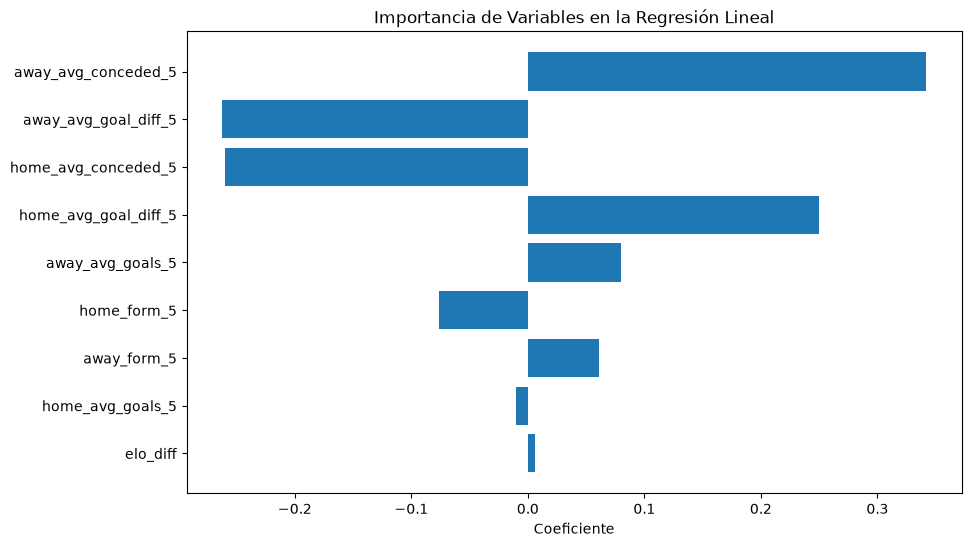

In [31]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lr_model.coef_
})

coef_df["Abs"] = abs(
    coef_df["Coeficiente"]
)

coef_df = coef_df.sort_values(
    by="Abs",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    coef_df["Variable"],
    coef_df["Coeficiente"]
)

plt.title(
    "Importancia de Variables en la Regresión Lineal"
)

plt.xlabel("Coeficiente")

plt.show()

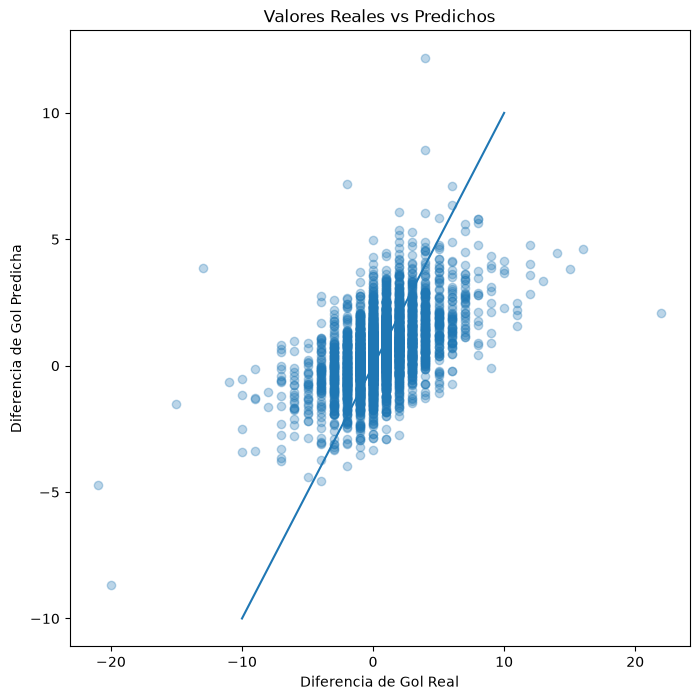

In [32]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.plot(
    [-10,10],
    [-10,10]
)

plt.xlabel(
    "Diferencia de Gol Real"
)

plt.ylabel(
    "Diferencia de Gol Predicha"
)

plt.title(
    "Valores Reales vs Predichos"
)

plt.show()

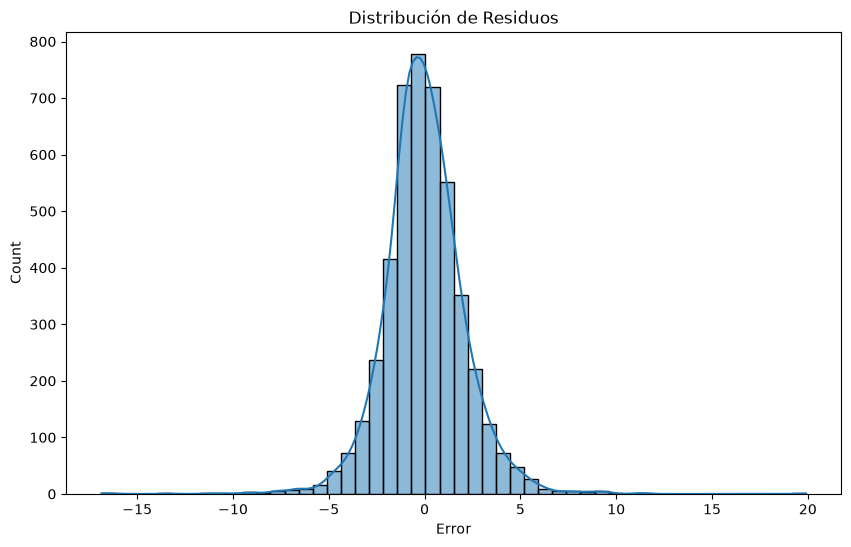

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title(
    "Distribución de Residuos"
)

plt.xlabel(
    "Error"
)

plt.show()

In [36]:
print("="*50)
print("LINEAR REGRESSION BASELINE")
print("="*50)
print(f"Número de variables: {len(features)}")
print(f"Entrenamiento: {len(X_train)} partidos")
print(f"Prueba: {len(X_test)} partidos")
print()
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

LINEAR REGRESSION BASELINE
Número de variables: 9
Entrenamiento: 18339 partidos
Prueba: 4585 partidos

MAE : 1.530
RMSE: 2.099
R²  : 0.257
